# Concatenating Historical and Current MUR SST Icechunk Stores

This notebook demonstrates how to open and concatenate two MUR SST virtual Icechunk stores:
- **Historical store (v1)**: Contains data from 2002-06-01 to 2024-06-01
- **Current store (v2-p2)**: Contains data from 2024-06-02 onwards

⚠️ You will need a [NASA Earthdata login username and password](https://urs.earthdata.nasa.gov/) and to run this notebook in the AWS us-west-2 region.

## Step 0. 📚 Install required libraries

In [1]:
%%capture
!pip install icechunk~=1.0.0 virtualizarr==1.3.0 xarray==2025.4.0 earthaccess==0.14.0 zarr==3.1.5

## Step 1. 📚 Import libraries 

And set Zarr concurrency (see [zarr.config](https://zarr.readthedocs.io/en/latest/user-guide/config/)).

In [2]:
from datetime import datetime, timedelta
import earthaccess
from icechunk import (
    VirtualChunkContainer,
    RepositoryConfig,
    Repository,
    containers_credentials,
    s3_storage,
    s3_store,
    s3_credentials
)
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

zarr.config.set({
    'async': {'concurrency': 100, 'timeout': None},
    'threading': {'max_workers': None}
})

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Step 2. 🔐 Authenticate with NASA Earthdata

Login to Earthdata to get credentials for accessing the protected S3 buckets.

In [3]:
earthaccess.login()
ea_creds = earthaccess.get_s3_credentials(daac='PODAAC')

Enter your Earthdata Login username:  aimeeb
Enter your Earthdata password:  ········


## Step 3: 🪣 Set data location constants

In [4]:
icechunk_bucket = 'nasa-eodc-public'
icechunk_historical_store_name = "MUR-JPL-L4-GLOB-v4.1-virtual-v1"
icechunk_current_store_name = "MUR-JPL-L4-GLOB-v4.1-virtual-v2-p2"
data_location_prefix = 's3://podaac-ops-cumulus-protected/MUR-JPL-L4-GLOB-v4.1/'

## Step 4. 🛠️ Define some opener functions

In [5]:
def open_repo(store_name: str) -> Repository:
    store_config = s3_store(region="us-west-2")
    
    # we create a container by giving it the url prefix and the store config
    container = VirtualChunkContainer(data_location_prefix, store_config)
    
    # we add it to the repo config
    config = RepositoryConfig.default()
    config.set_virtual_chunk_container(container)
    
    # we set credentials for the virtual chunk container
    # repo readers will also need this to be able to resolve the virtual chunks
    credentials = containers_credentials(
        {
            data_location_prefix: s3_credentials(
                access_key_id=ea_creds['accessKeyId'],
                secret_access_key=ea_creds['secretAccessKey'],
                session_token=ea_creds['sessionToken']
            )
        }
    )
    
    storage = s3_storage(
        bucket=icechunk_bucket,
        prefix=f"icechunk/{store_name}",
        anonymous=True
    )

    # When we create the repo, its configuration will be saved to disk
    # including its virtual chunk containers
    repo = Repository.open(
        storage=storage,
        config=config,
        authorize_virtual_chunk_access=credentials,
    )
    return repo

def open_readonly_store(store_name: str):
    repo = open_repo(store_name)
    session = repo.readonly_session('main')
    return zarr.open(session.store, mode="r")
    

## Step 5: 📦 Open each store

In [6]:
historical_store = open_readonly_store(icechunk_historical_store_name)
current_store = open_readonly_store(icechunk_current_store_name)

## Step 6. 🕛 Concatenate the time arrays

In [8]:
%%time
epoch = datetime(1981, 1, 1)
# The checksum for 2025-11-13 is broken so we just use the data up until that point
current_store_end = 529
historical_time_array = np.array([epoch + timedelta(seconds=int(t)) for t in historical_store['time'][:]])
current_time_array = np.array([epoch + timedelta(seconds=int(t)) for t in current_store['time'][:current_store_end]])
all_times = np.concatenate([historical_time_array, current_time_array])

CPU times: user 6.7 s, sys: 1.37 s, total: 8.06 s
Wall time: 11 s


In [9]:
current_time_array[-1]

datetime.datetime(2025, 11, 12, 9, 0)

## Step 7: 🌊 Construct a spatial subset of sea surface temperature (SST)

### 7a: Determine the indices of the spatial subset

In [10]:
lat_min, lon_min = -90, -180
resolution = 0.01
lat_range = [47.5, 48.5]
lon_range = [-125.5, -124.5]
lat_indices = [int((lat - lat_min)/resolution) for lat in lat_range]
lon_indices = [int((lon - lon_min)/resolution) for lon in lon_range]

### 7b: Spatially subset the SST arrays

In [11]:
%%time
sst_subset_historical = historical_store["analysed_sst"][:, lat_indices[0]:lat_indices[1], lon_indices[0]:lon_indices[1]]
sst_subset_current = current_store["analysed_sst"][:current_store_end, lat_indices[0]:lat_indices[1], lon_indices[0]:lon_indices[1]]

CPU times: user 3min 17s, sys: 33.6 s, total: 3min 50s
Wall time: 1min 15s


### 7c: Concatenate the SST arrays

And verify the shapes are as expected.

In [12]:
all_ssts = np.concatenate([sst_subset_historical, sst_subset_current])
all_times.shape, all_ssts.shape

((8566,), (8566, 100, 100))

## Step 8: 🎭 Mask, average and scale data

In [13]:
fill_value = historical_store["analysed_sst"].fill_value
sst_attrs = historical_store["analysed_sst"].metadata.attributes
offset, scale = sst_attrs['add_offset'], sst_attrs['scale_factor']

# mask the the data using the fill value
masked_array = np.ma.masked_equal(all_ssts, fill_value)

# calculate the average over space, for all time steps
sst_mean = masked_array.mean(axis=(1,2))

# apply the scale and offset
scaled_sst_mean = (sst_mean*scale) + offset

## 📈 Final Step! Plot the data

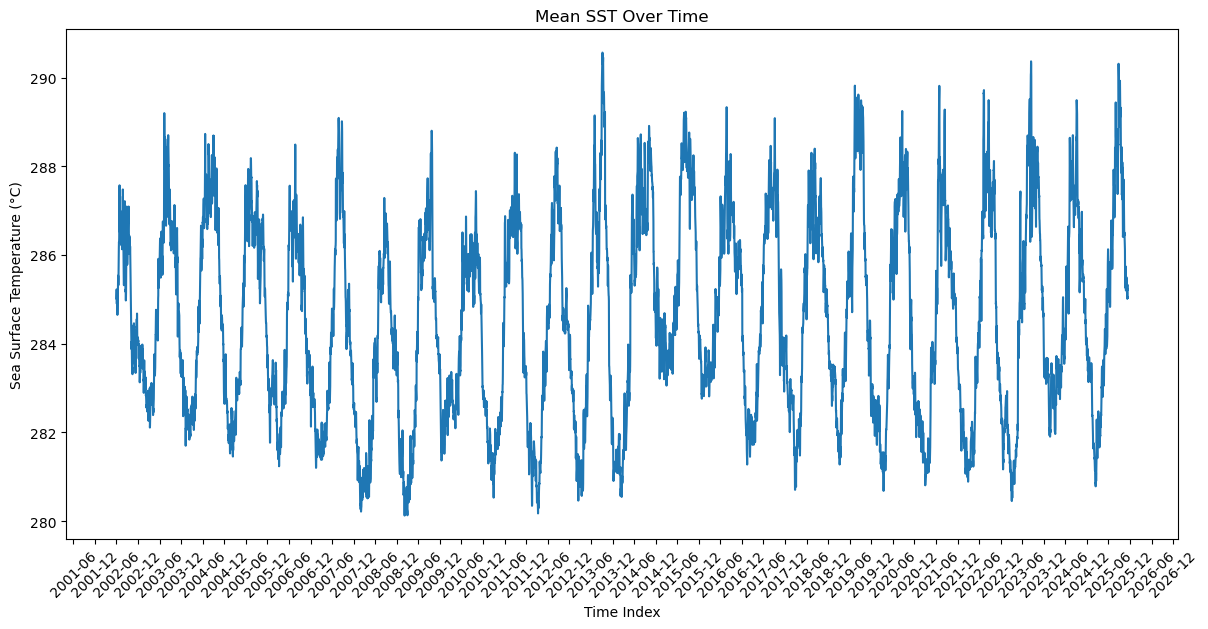

In [14]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(all_times, scaled_sst_mean)

# Set major ticks to months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Mean SST Over Time")
plt.xlabel("Time Index")
plt.ylabel("Sea Surface Temperature (°C)")  # Replace with correct units
plt.show()